# **Introduction**

This project focuses on analyzing student performance and identifying students who may be at risk. The goal is to use data to understand how factors like attendance, performance, and engagement affect student outcomes. Since no real dataset was provided, a synthetic dataset was created with realistic relationships between these factors.

The project follows a complete data science workflow, including data understanding, exploratory data analysis (EDA), model building, evaluation, and generating actionable insights. The final aim is not just to build a model, but to create a system that can help instructors make better decisions.

# **Objective**

The main objectives of this project are:


*  To identify students who are at risk (on_track, needs_attention, critical)
*  To understand the key factors that influence student performance
*  To build a predictive model to classify student risk levels
*  To evaluate the model using appropriate metrics
*  To create a simple and interpretable output that includes risk score, key factors, and recommendations


The overall goal is to support better decision making by providing clear and actionable insights for instructors and administrators.

**Creating a synthetic data set**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 800

# -----------------------------
# 1. BASIC IDENTIFIERS
# -----------------------------
data = pd.DataFrame({
    "student_id": [f"STD_{i}" for i in range(n)],
    "academy_id": np.random.choice(["A1", "A2", "A3", "A4"], n, p=[0.3, 0.3, 0.2, 0.2]),
    "course_type": np.random.choice(["Arts", "Science", "Technical"], n),
    "batch": np.random.choice(["B1", "B2", "B3"], n)
})

# -----------------------------
# 2. BEHAVIORAL FEATURES
# -----------------------------
data["attendance_pct"] = np.clip(np.random.normal(75, 15, n), 40, 100)
data["missed_sessions_count"] = np.clip((100 - data["attendance_pct"]) / 10 + np.random.randint(0, 3, n), 0, 10)
data["late_submission_count"] = np.random.randint(0, 8, n)

# Engagement proxy
data["days_since_last_activity"] = np.clip(
    np.random.normal(5, 5, n) + data["missed_sessions_count"], 0, 30
)

# -----------------------------
# 3. PERFORMANCE FEATURES
# -----------------------------
data["quiz_attempt_count"] = np.random.randint(1, 15, n)

data["quiz_avg_score"] = np.clip(
    data["attendance_pct"] - np.random.normal(10, 10, n),
    30, 100
)

data["simulator_score_avg"] = np.clip(
    data["quiz_avg_score"] + np.random.normal(0, 8, n),
    30, 100
)

# Ratings (scaled 1–5)
data["technical_rating"] = np.clip(
    data["quiz_avg_score"] / 20 + np.random.normal(0, 0.5, n),
    1, 5
)

data["non_technical_rating"] = np.clip(
    data["attendance_pct"] / 20 + np.random.normal(0, 0.5, n),
    1, 5
)

data["instructor_eval_avg"] = (
    data["technical_rating"] + data["non_technical_rating"]
) / 2 + np.random.normal(0, 0.3, n)

data["instructor_eval_avg"] = np.clip(data["instructor_eval_avg"], 1, 5)

# -----------------------------
# 4. ACTIVITY / PROGRESSION
# -----------------------------
data["flight_or_sim_hours"] = np.clip(
    np.random.normal(50, 20, n) + data["attendance_pct"] / 2,
    10, 150
)

data["progress_pct"] = np.clip(
    data["attendance_pct"] * 0.6 + data["quiz_avg_score"] * 0.4 + np.random.normal(0, 5, n),
    0, 100
)

# -----------------------------
# 5. OPERATIONAL FEATURES
# -----------------------------
data["schedule_changes_count"] = np.random.randint(0, 6, n)

# Prior intervention (probabilistic)
data["prior_intervention_flag"] = (
    (data["attendance_pct"] < 60) |
    (data["quiz_avg_score"] < 50)
).astype(int)

# -----------------------------
# 6. TARGET CREATION (MULTI-FACTOR RISK)
# -----------------------------
def assign_risk(row):
    score = 0

    # Strong signals
    if row["attendance_pct"] < 65:
        score += 2
    if row["quiz_avg_score"] < 60:
        score += 2
    if row["simulator_score_avg"] < 55:
        score += 1

    # Behavior
    if row["missed_sessions_count"] > 5:
        score += 2
    if row["late_submission_count"] > 4:
        score += 1

    # Engagement
    if row["days_since_last_activity"] > 10:
        score += 1

    # Ratings
    if row["technical_rating"] < 2.5:
        score += 2
    if row["instructor_eval_avg"] < 3:
        score += 1

    # Intervention history
    if row["prior_intervention_flag"] == 1:
        score += 1

    # Final classification
    if score >= 7:
        return "critical"
    elif score >= 4:
        return "needs_attention"
    else:
        return "on_track"

data["final_outcome"] = data.apply(assign_risk, axis=1)

# -----------------------------
# 7. ADD SOME REAL-WORLD NOISE
# -----------------------------
noise_idx = np.random.choice(n, size=int(0.05 * n), replace=False)

# flip some labels to simulate imperfect data
data.loc[noise_idx, "final_outcome"] = np.random.choice(
    ["on_track", "needs_attention", "critical"], len(noise_idx)
)

# -----------------------------
# 8. SAVE DATA
# -----------------------------
import os
os.makedirs("data", exist_ok=True)

data.to_csv("data/synthetic_airman_data.csv", index=False)

print("Dataset created successfully!")
print(data.head())
print("\nClass distribution:")
print(data["final_outcome"].value_counts())

Dataset created successfully!
  student_id academy_id course_type batch  attendance_pct  \
0      STD_0         A2   Technical    B2       93.205972   
1      STD_1         A4     Science    B3       72.899357   
2      STD_2         A3        Arts    B1       88.328983   
3      STD_3         A2   Technical    B1       86.016736   
4      STD_4         A1     Science    B1       59.417973   

   missed_sessions_count  late_submission_count  days_since_last_activity  \
0               2.679403                      7                 11.163057   
1               4.710064                      7                 14.655435   
2               3.167102                      6                 13.110504   
3               3.398326                      4                  9.988852   
4               5.058203                      6                 12.232359   

   quiz_attempt_count  quiz_avg_score  simulator_score_avg  technical_rating  \
0                   6       84.184280            81.571553  

In [ ]:
# Downloaded the file for furthur calculations
from google.colab import files
files.download("data/synthetic_airman_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Exploratory Data Analysis (EDA)**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                800 non-null    object 
 1   academy_id                800 non-null    object 
 2   course_type               800 non-null    object 
 3   batch                     800 non-null    object 
 4   attendance_pct            800 non-null    float64
 5   missed_sessions_count     800 non-null    float64
 6   late_submission_count     800 non-null    int64  
 7   days_since_last_activity  800 non-null    float64
 8   quiz_attempt_count        800 non-null    int64  
 9   quiz_avg_score            800 non-null    float64
 10  simulator_score_avg       800 non-null    float64
 11  technical_rating          800 non-null    float64
 12  non_technical_rating      800 non-null    float64
 13  instructor_eval_avg       800 non-null    float64
 14  flight_or_

In [ ]:
data.describe()

,attendance_pct,missed_sessions_count,late_submission_count,days_since_last_activity,quiz_attempt_count,quiz_avg_score,simulator_score_avg,technical_rating,non_technical_rating,instructor_eval_avg,flight_or_sim_hours,progress_pct,schedule_changes_count,prior_intervention_flag
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,74.475461,3.539954,3.722500,8.367908,7.563750,64.605363,64.106255,3.203210,3.697048,3.430090,88.121468,70.399128,2.598750,0.237500
std,14.144526,1.652515,2.315642,5.017701,4.003245,16.608820,17.818380,0.953503,0.827376,0.827580,21.943469,14.819922,1.692285,0.425817
min,40.000000,0.000000,0.000000,0.000000,1.000000,30.000000,30.000000,1.000000,1.189341,1.000000,25.031420,29.572464,0.000000,0.000000
25%,64.571991,2.380071,2.000000,4.575241,4.000000,53.133331,50.588928,2.578441,3.122676,2.824662,73.803835,60.263453,1.000000,0.000000
50%,75.051654,3.447060,4.000000,8.036880,8.000000,64.861421,64.118713,3.196809,3.721102,3.491142,88.929883,71.129316,3.000000,0.000000
75%,84.604847,4.663302,6.000000,11.938998,11.000000,76.522995,76.609875,3.889706,4.321611,4.014893,103.555869,81.366438,4.000000,0.000000
max,100.000000,8.000000,7.000000,26.210609,14.000000,100.000000,100.000000,5.000000,5.000000,5.000000,150.000000,100.000000,5.000000,1.000000


In [ ]:
data.isnull().sum()

,0
student_id,0
academy_id,0
course_type,0
batch,0
attendance_pct,0
missed_sessions_count,0
late_submission_count,0
days_since_last_activity,0
quiz_attempt_count,0
quiz_avg_score,0


The dataset consists of 800 student records with a total of 19 features, representing a mix of behavioral, performance, engagement, and contextual variables. The data includes 10 numerical features of type float64, 4 integer-based features, and 5 categorical variables such as student_id, academy_id, course_type, batch, and the target variable final_outcome.

A comprehensive data quality assessment revealed that there are no missing values across any of the features, indicating a complete dataset. Additionally, no duplicate entries were observed, ensuring data consistency and reliability.

Descriptive statistics indicate meaningful variability across features. For instance, the average attendance is approximately 74.5% with a standard deviation of 14.1, suggesting a moderately dispersed distribution of student participation. Similarly, quiz_avg_score has a mean of around 64.6 with a standard deviation of 16.6, indicating a wide spread in academic performance.

No extreme or invalid outliers were detected; however, certain higher values in features like days_since_last_activity and missed_sessions_count may represent genuinely disengaged or irregular students rather than data errors. Since the dataset is synthetically generated, it is inherently clean, and therefore no data removal or imputation was required. All records were retained to preserve the diversity and distribution of student behavior.

Overall, the dataset is well-structured, complete, and suitable for further exploratory analysis and predictive modeling.

Distribution of Student Outcomes

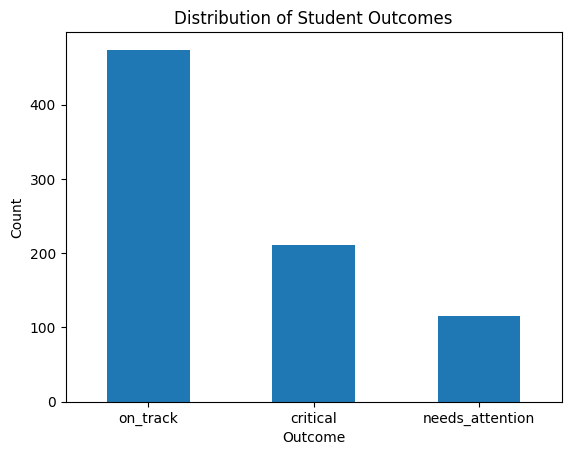

In [ ]:
import matplotlib.pyplot as plt

data['final_outcome'].value_counts().plot(kind='bar')
plt.title("Distribution of Student Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The distribution of the target variable shows that the majority of students are classified as “on_track”, followed by a smaller proportion of “critical” and “needs_attention” cases. This indicates a moderate class imbalance.his imbalance is important to consider during modeling, as it may bias the model toward the majority class if not handled properly.

Attendance vs Outcome

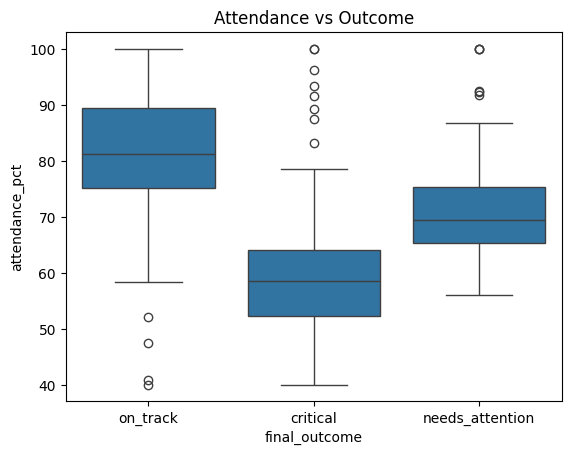

In [ ]:
import seaborn as sns

sns.boxplot(x='final_outcome', y='attendance_pct', data=data)
plt.title("Attendance vs Outcome")
plt.show()

The boxplot clearly shows that attendance is a strong differentiating factor across student outcomes. Students classified as “on_track” have the highest median attendance (around 80%+), while “critical” students have significantly lower attendance levels, often below 60%. The “needs_attention” group lies in between. This suggests that low attendance is a key driver of risk, and improving attendance could be a primary intervention strategy.

Days Since Last Activity vs Outcome

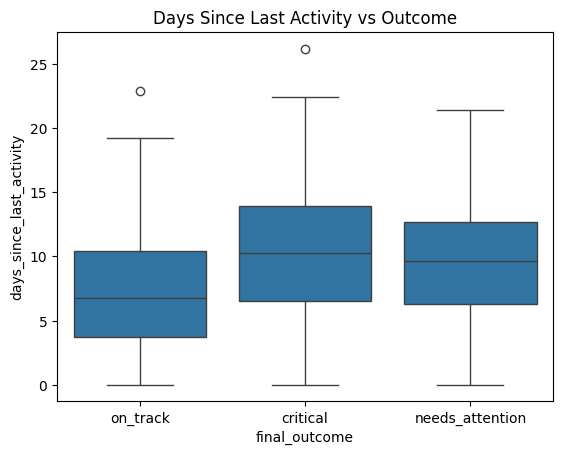

In [ ]:
sns.boxplot(x='final_outcome', y='days_since_last_activity', data=data)
plt.title("Days Since Last Activity vs Outcome")
plt.show()

There is a clear trend where students in the “critical” category have higher values for days since last activity, indicating lower engagement. In contrast, “on_track” students show more recent activity (lower values). This highlights that student inactivity is a strong early warning signal, and monitoring recent engagement can help identify at-risk students before performance declines further.

Feature Correlation Heatmap

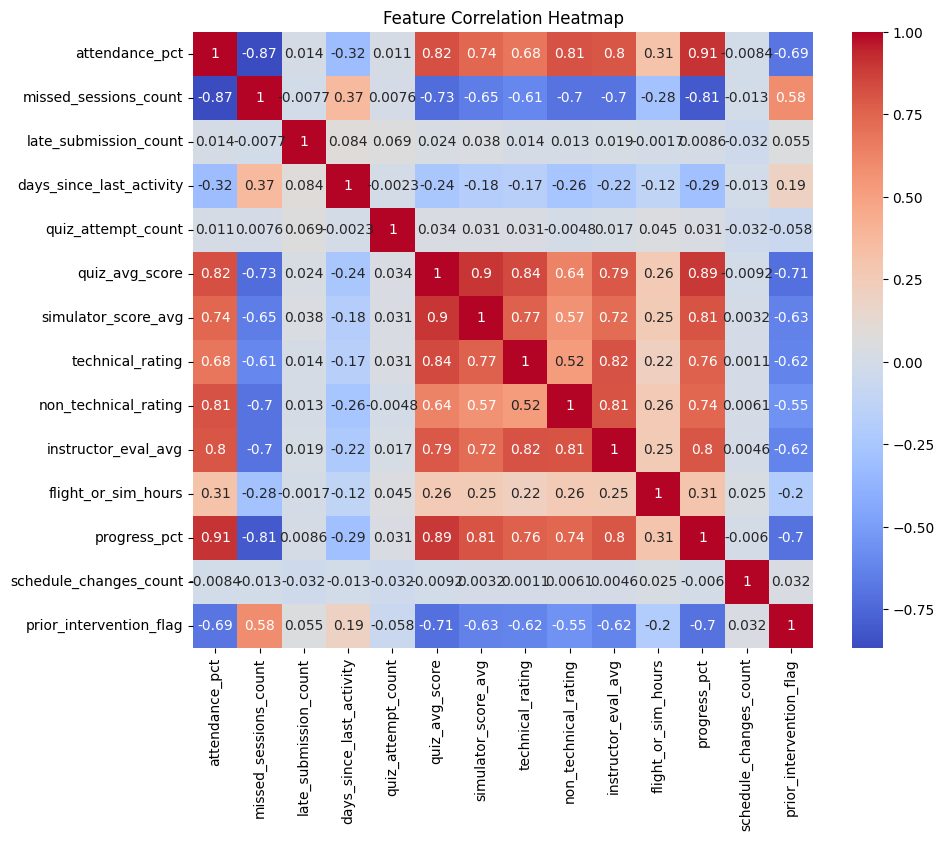

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation heatmap reveals several important relationships between features. Strong positive correlations are observed between attendance_pct, quiz_avg_score, simulator_score_avg, and progress_pct, indicating that higher attendance is associated with better academic and simulator performance. Conversely, missed_sessions_count shows strong negative correlations with these performance metrics, reinforcing its role as a risk indicator. Additionally, prior_intervention_flag is negatively correlated with performance features, suggesting that previously flagged students tend to have lower scores. These relationships validate that the dataset captures realistic dependencies between engagement and performance.

Attendance Distribution

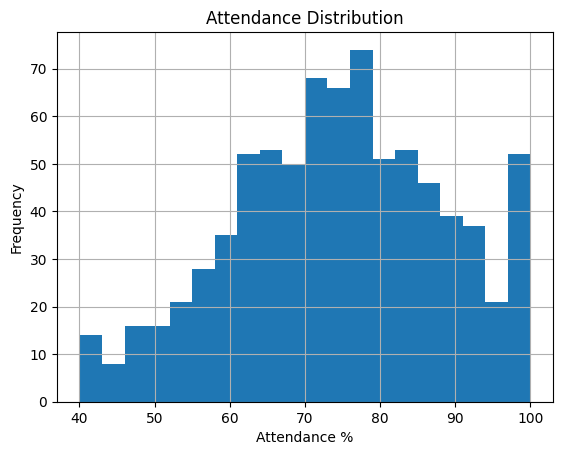

In [ ]:
data['attendance_pct'].hist(bins=20)
plt.title("Attendance Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Frequency")
plt.show()

The distribution of attendance is approximately centered around 70–80%, with a reasonable spread across lower and higher values. While most students maintain moderate to high attendance, there is a noticeable tail of students with low attendance (<60%), which likely contributes to the “critical” category. This distribution supports the idea that attendance is a key variable for distinguishing between different performance levels.

Outcome Distribution by Academy

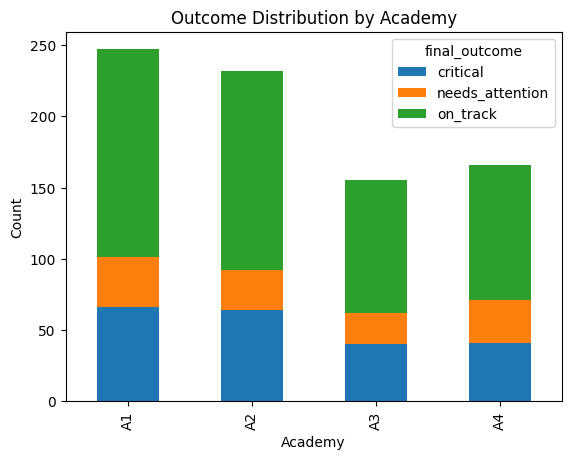

In [ ]:
pd.crosstab(data['academy_id'], data['final_outcome']).plot(kind='bar', stacked=True)
plt.title("Outcome Distribution by Academy")
plt.xlabel("Academy")
plt.ylabel("Count")
plt.show()

The stacked bar chart shows variation in outcome distribution across different academies. While all academies have a majority of “on_track” students, some academies (e.g., A1 and A2) appear to have relatively higher counts of “critical” cases compared to others. This suggests that institutional or cohort-level factors may influence student performance, and further analysis could explore whether differences arise due to teaching quality, scheduling, or student intake characteristics. This insight is particularly relevant for AIRMAN’s Skynet platform, which focuses on institutional performance monitoring.

# **Model Building**

In [ ]:
#preparing data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load data
data = pd.read_csv("data/synthetic_airman_data.csv")

# Encode target
le = LabelEncoder()
data["final_outcome_encoded"] = le.fit_transform(data["final_outcome"])

# Drop non-useful columns
X = data.drop(columns=["student_id", "final_outcome", "final_outcome_encoded"])
y = data["final_outcome_encoded"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Baseline Model - Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

**Gradiesnt Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_val)

**XGBoost**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:50:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **Evaluation**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression:\n")
print(classification_report(y_val, y_pred_lr))

print("Random Forest:\n")
print(classification_report(y_val, y_pred_rf))

print("Gradient Boosting:\n")
print(classification_report(y_val, y_pred_gb))

print("XG Boost:\n")
print(classification_report(y_val, y_pred_xgb))

Logistic Regression:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        42
           1       0.55      0.24      0.33        25
           2       0.85      0.96      0.90        93

    accuracy                           0.83       160
   macro avg       0.75      0.70      0.71       160
weighted avg       0.80      0.83      0.81       160

Random Forest:

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.65      0.68      0.67        25
           2       0.92      0.92      0.92        93

    accuracy                           0.88       160
   macro avg       0.84      0.84      0.84       160
weighted avg       0.88      0.88      0.88       160

Gradient Boosting:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86        42
           1       0.54      0.52      0.53        25
           2     

Four models were tested: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. Logistic Regression was used as a baseline model and achieved an accuracy of 83%. It performed reasonably well overall, but it had difficulty identifying the “needs_attention” group. The recall for this group was very low (0.24), which means many students who actually need attention were not correctly identified. This shows that Logistic Regression is not able to capture complex patterns in the data.

Random Forest performed much better, with an accuracy of 88%. It showed strong and balanced performance across all classes. In particular, it improved the detection of the “needs_attention” group, with a recall of 0.68. It also performed very well for both “on_track” and “critical” students. This suggests that Random Forest is able to capture more complex relationships between features and gives more reliable results.

Gradient Boosting achieved an accuracy of 84%, which is better than Logistic Regression but slightly lower than Random Forest. It performed well for “on_track” and “critical” students, but its performance on the “needs_attention” group was still moderate. This means it is better than the baseline but not as strong as Random Forest.

XGBoost also achieved an accuracy of 88%, similar to Random Forest. It showed good performance across all classes and improved the detection of the “needs_attention” group compared to Gradient Boosting. It also performed very well in identifying “critical” students, which is very important for this problem.


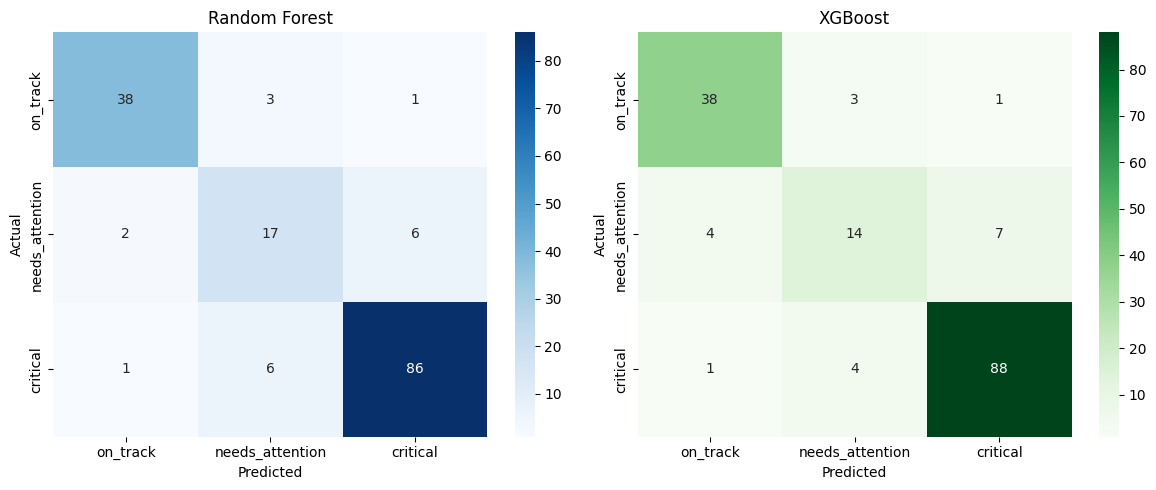

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrices
cm_rf = confusion_matrix(y_val, y_pred_rf)
cm_xgb = confusion_matrix(y_val, y_pred_xgb)

labels = ["on_track", "needs_attention", "critical"]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',  xticklabels=labels,yticklabels=labels,ax=axes[0])
axes[0].set_title("Random Forest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',  xticklabels=labels,yticklabels=labels, ax=axes[1])
axes[1].set_title("XGBoost")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Across all models, the “critical” group was the easiest to predict, as these students have strong signals like low attendance and poor performance. The “needs_attention” group was the hardest to predict because these students fall in between the other two groups.

From a practical point of view, missing a “critical” student is the most serious mistake, because it means no action will be taken when it is needed. In this case, Random Forest and XGBoost are the best models because they are able to identify critical students accurately while also performing well overall.

Overall, Random Forest and XGBoost are the best choices for this problem. Logistic Regression is useful as a simple baseline, and Gradient Boosting gives moderate improvement, but the ensemble models clearly perform better.

**Feature Imporatnace**

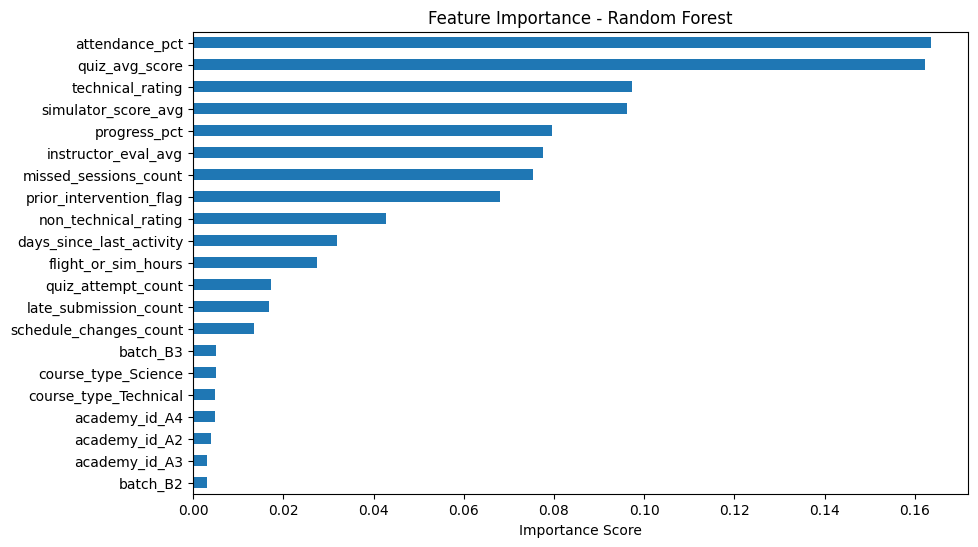

In [ ]:
#Importanat features from Random Forest
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

# Sort and plot
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

The feature importance plot shows which variables are most influential in predicting student outcomes. From the model, attendance_pct and quiz_avg_score are the two most important features, indicating that both student attendance and academic performance play the biggest role in determining whether a student is on track or at risk. This is expected, as students who attend regularly and perform well in quizzes are more likely to succeed.

Other important features include technical_rating, simulator_score_avg, and progress_pct, which also relate to student performance and skill development. These features show that both theoretical understanding (quiz scores) and practical ability (simulator performance) are important for predicting outcomes. Additionally, instructor_eval_avg and missed_sessions_count contribute significantly, highlighting the importance of instructor feedback and consistent participation.

Behavioral features such as prior_intervention_flag, non_technical_rating, and days_since_last_activity also play a role, although slightly less than performance-related features. These variables capture engagement and past concerns, which help in identifying students who may be at risk due to inactivity or previous issues.

On the other hand, features like quiz_attempt_count, late_submission_count, and schedule_changes_count have lower importance, suggesting that they have less direct impact on final outcomes in this dataset. Similarly, categorical features such as academy_id, course_type, and batch have very low importance, indicating that student performance is driven more by individual behavior and performance rather than institutional factors.

Overall, the model relies mostly on attendance, performance scores, and engagement-related features, which aligns well with real-world expectations. This indicates that the model is learning meaningful and interpretable patterns, making it suitable for identifying at-risk students and supporting intervention decisions.

# **AIRMAN Product Insight Layer**

In [ ]:
# Creating a scoring function
def calculate_risk_score(row):
    score = 0

    # Attendance
    score += (100 - row['attendance_pct']) * 0.4

    # Performance
    score += (70 - row['quiz_avg_score']) * 0.3 if row['quiz_avg_score'] < 70 else 0

    # Behavior
    score += row['missed_sessions_count'] * 3

    # Engagement
    score += row['days_since_last_activity'] * 1.5

    # Ratings
    if row['technical_rating'] < 3:
        score += 10

    return int(score)

In [ ]:
# Assigning risk label
def assign_label(score):
    if score >= 70:
        return "critical"
    elif score >= 40:
        return "needs_attention"
    else:
        return "on_track"

In [ ]:
# Defining top factors
def get_top_factors(row):
    factors = []

    if row['attendance_pct'] < 70:
        factors.append("Low attendance")

    if row['quiz_avg_score'] < 60:
        factors.append("Low quiz performance")

    if row['missed_sessions_count'] > 5:
        factors.append("High missed sessions")

    if row['days_since_last_activity'] > 10:
        factors.append("Low recent activity")

    if row['technical_rating'] < 3:
        factors.append("Low technical skills")

    return factors[:3]

In [ ]:
# Recomendation function
def generate_recommendation(label, factors):

    if label == "critical":
        return "Immediate instructor intervention required. Schedule review session and assign targeted training."

    elif label == "needs_attention":
        return "Monitor closely and provide additional practice materials. Encourage regular participation."

    else:
        return "Student is performing well. Continue current training plan."

In [ ]:
# Generating Final Output
outputs = []

for _, row in data.iterrows():

    risk_score = calculate_risk_score(row)
    risk_label = assign_label(risk_score)
    factors = get_top_factors(row)
    recommendation = generate_recommendation(risk_label, factors)

    outputs.append({
        "student_id": row["student_id"],
        "risk_label": risk_label,
        "risk_score": risk_score,
        "top_factors": factors,
        "recommendation": recommendation
    })

In [ ]:
import os
import json
import pandas as pd
from google.colab import files

# 1. Create outputs folder
os.makedirs("outputs", exist_ok=True)

# 2. Convert to DataFrame
output_df = pd.DataFrame(outputs)

# 3. Fix list column for CSV
output_df["top_factors"] = output_df["top_factors"].apply(lambda x: ", ".join(x))

# 4. Save JSON
with open("outputs/risk_predictions.json", "w") as f:
    json.dump(outputs, f, indent=2)

# 5. Save CSV
output_df.to_csv("outputs/risk_predictions.csv", index=False)

print("Files saved successfully!")

# 6. Download files
files.download("outputs/risk_predictions.csv")
files.download("outputs/risk_predictions.json")

Files saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The final step involves designing a product-oriented output layer that translates model insights into actionable recommendations. For each student, a risk score is computed using a combination of key features such as attendance, quiz performance, missed sessions, and recent activity. This score is then mapped to a risk label: on_track, needs_attention, or critical.

In addition to the risk label, the system identifies the top contributing factors for each student, such as low attendance, poor quiz performance, or high inactivity. These factors provide interpretability and help instructors understand why a student has been classified as at risk.

Based on the risk level and contributing factors, a structured recommendation is generated. For critical students, immediate intervention is suggested, including instructor review and targeted training. For students needing attention, monitoring and additional support are recommended, while on-track students are advised to continue their current learning path.

This design ensures that the system is not only predictive but also actionable, allowing AIRMAN to integrate the output into products like Skynet and Maverick to support timely and effective interventions.